In [1053]:
from meta import ROOT_DIR
import matplotlib.pyplot as plt
import numpy as np
import scipy
from bez.topo_graph import * 
from bez.hypergraph import HyperGraph
from bez.bezier import fit_bezier, interpolate_bezier, fitting_error
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1054]:
skeleton = np.array(
    [
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    ], dtype=bool
)

topo = extract_topology_from_skeleton(skeleton)

In [1055]:
hyper = HyperGraph(topo)

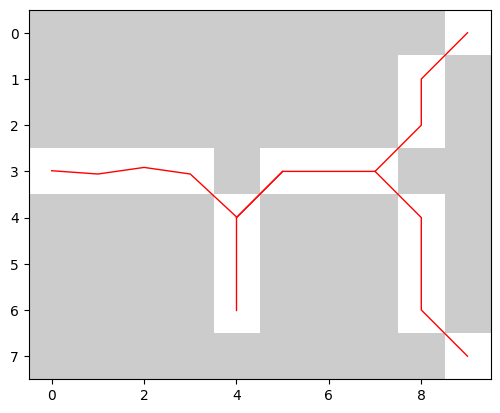

In [1056]:
plt.imshow(skeleton, cmap="gray", alpha=0.2)
for h in hyper.all_hyperedges():
    p = np.array(h.pixels).T
    instants = np.linspace(0, 1, p.shape[1])
    control_points = fit_bezier(p, instants, degree=h.degree)
    traj = interpolate_bezier(control_points, instants)
    plt.plot(traj[1], traj[0], color='red', linewidth=1)

In [1057]:
def score(hyperedge, c):
    u_simplicity = 1 + hyperedge.degree
    p = np.array(hyperedge.pixels).T

    try:
        instants = np.linspace(0, 1, p.shape[1])
        control_points = fit_bezier(p, instants, degree=hyperedge.degree)
        traj = interpolate_bezier(control_points, instants)
        u_fidelity = fitting_error(traj, p)
        return (1-c)*u_fidelity + c*u_simplicity
    except np.linalg.LinAlgError:
        return float("inf")

In [1058]:
c = 0.5
temp = 1
error = [sum([score(x, c) for x in hyper.all_hyperedges()])]
for i in range(10000):
    choice, old, new = hyper.propose_random_perturbation()
    delta = sum([score(x, c) for x in new]) - sum([score(x, c) for x in old])
    p = np.random.random()
    if p < np.exp(-delta / temp):
        if delta > 0:
            print(choice)
        hyper.perturbate(old, new)
        error.append(error[-1]+delta)
    else:
        error.append(error[-1])
    temp = temp * 0.999

Perturbation.OVERLAP
Perturbation.INCREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.OVERLAP
Perturbation.INCREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.INCREASE_DEGREE
Perturbation.OVERLAP
Perturbation.DECREASE_DEGREE
Perturbation.DECREASE_DEGREE
Perturbat

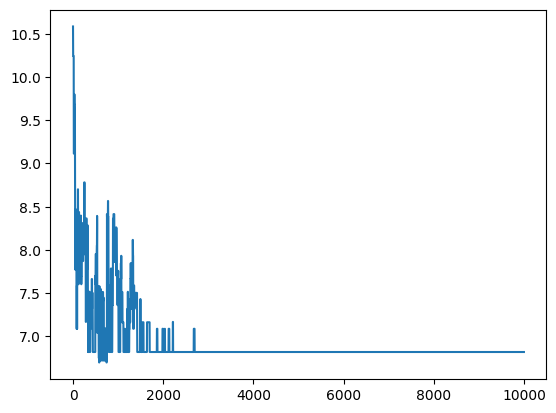

In [1059]:
plt.plot(range(len(error)), error)

In [1060]:
hyper.all_hyperedges()

AtlasView({(0, 9) - [0] -> (3, 7) ( degree = 1, n_pixels = 4): {}, (3, 0) - [0] -> (4, 4) - [0] -> (6, 4) ( degree = 2, n_pixels = 7): {}, (7, 9) - [0] -> (3, 7) - [0] -> (4, 4) - [0] -> (3, 5) ( degree = 2, n_pixels = 9): {}})

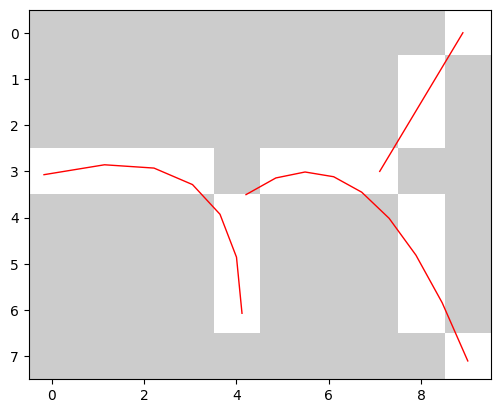

In [1061]:
plt.imshow(skeleton, cmap="gray", alpha=0.2)
for h in hyper.all_hyperedges():
    p = np.array(h.pixels).T
    instants = np.linspace(0, 1, p.shape[1])
    control_points = fit_bezier(p, instants, degree=h.degree)
    traj = interpolate_bezier(control_points, instants)
    plt.plot(traj[1], traj[0], color='red', linewidth=1)

In [1006]:
hyper.g.adj["*"]

AtlasView({(3, 7) - [0] -> (0, 9) ( degree = 3, n_pixels = 4): {}, (3, 7) - [0] -> (7, 9) ( degree = 3, n_pixels = 5): {}, (3, 0) - [0] -> (4, 4) - [0] -> (3, 5) ( degree = 1, n_pixels = 6): {}, (6, 4) - [0] -> (4, 4) - [0] -> (3, 7) ( degree = 2, n_pixels = 6): {}})

In [649]:
np.linalg.LinAlgError

numpy.linalg.LinAlgError